<a id="inicio-notebook"></a>
# Proyecto End to End de Machine Learning 
### Viviendas en venta en Madrid


## 0. Librerías
 

In [4]:
# importación agrupada de librerías necesarias en este notebook
import pandas as pd
import numpy as np


import sys
import os
from datetime import date

from scipy import stats
from scipy.stats import chi2_contingency
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error,make_scorer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, BayesianRidge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor  # Asegúrate de tener XGBoost instalado
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, GridSearchCV

from skopt import BayesSearchCV
from skopt.space import Integer, Real

import matplotlib.pyplot as plt
import seaborn as sns

# import shap
# import lime
# from lime import lime_tabular

#warnings.filterwarnings('ignore')

# Añado el directorio padre (del que está este notebook) a sys.path
sys.path.append(os.path.abspath('../'))
from scripts.utils_agv import ini_inspec, crear_tabla_resumen, categoricas, numericas

### Configuración para visualizaciones

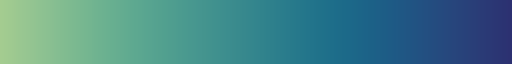

In [3]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.color_palette("crest", as_cmap=True)

<a id="testdata"></a> 
## Carga datos test
(equivalente a nuevos datos futuros)

In [7]:
# introduzco aquí el Dataframe en cuestión 
file = 'test_sinOutliers_df5.parquet'
file_path = f'../data/processed/{file}' 
df = pd.read_parquet(file_path, engine="pyarrow")
df.head(2)

,priceLog,terraza,numPhotos,floor,size,exterior,rooms,bathrooms,hasVideo,status,...,barrio_Chueca-Justicia,barrio_Huertas-Cortes,barrio_Lavapiés-Embajadores,barrio_Malasaña-Universidad,barrio_Palacio,barrio_Sol,tipo_flat,tipo_studio,tipo_penthouse,tipo_duplex
ID,,,,,,,,,,,,,,,,,,,,,
107478162,12.542188,0,26,0.0,41.0,0,1,1,1,1,...,0,0,0,0,1,0,1,0,0,0
107392397,13.369223,0,28,1.0,77.0,1,3,2,0,1,...,0,0,1,0,0,0,1,0,0,0


Si los datos que nos llegan no han sufrido mi proceso de transformación, etc, he de aplicar todo lo que hice con train, salvo eliminar observaciones (filas que consideré outliers), y en la siguiente celda de código está todo resumido.

### Preparación datos de test para modelos ML, separación X e y

Separo la target, en el caso de que el conjunto de test la contenga (no la contendrá si son datos nuevos sin precio)

In [ ]:
#Adaptar los datos que me llegan para mi modelo de ML
if 'priceLog' in df.columns:  # Caso 1: Si df contiene 'priceLog'
    X = df.drop(['priceLog'], axis=1)
    y = df['priceLog']

elif 'price' in df.columns:  # Caso 2: Si df contiene 'price'
    df['priceLog'] = np.log(df['price'])  # Aplicar transformación logarítmica
    X = df.drop(['priceLog'], axis=1)
    y = df['priceLog']

else:  # Caso 3: Si no contiene 'price' ni 'priceLog'
    X = df
    y = None  # y no existe en este caso


### Aplicación del modelo ML seleccionado

In [10]:
from joblib import load

mejor_ridge = load('mejorRegresionRidge.joblib')
mejor_ridge

Ridge(alpha=0.01, max_iter=1000)

### Algunas comprobaciones

<a id="resultados"></a>
<a href="#inicio-notebook"><p style="text-align:right;" href="#inicio-notebook">Volver al inicio</p></a> 
## 20. Resultados

Métricas finales del mejor modelo (Regresión Ridge):
RMSE: 222212.5301 €
MAPE: 18.7003 %


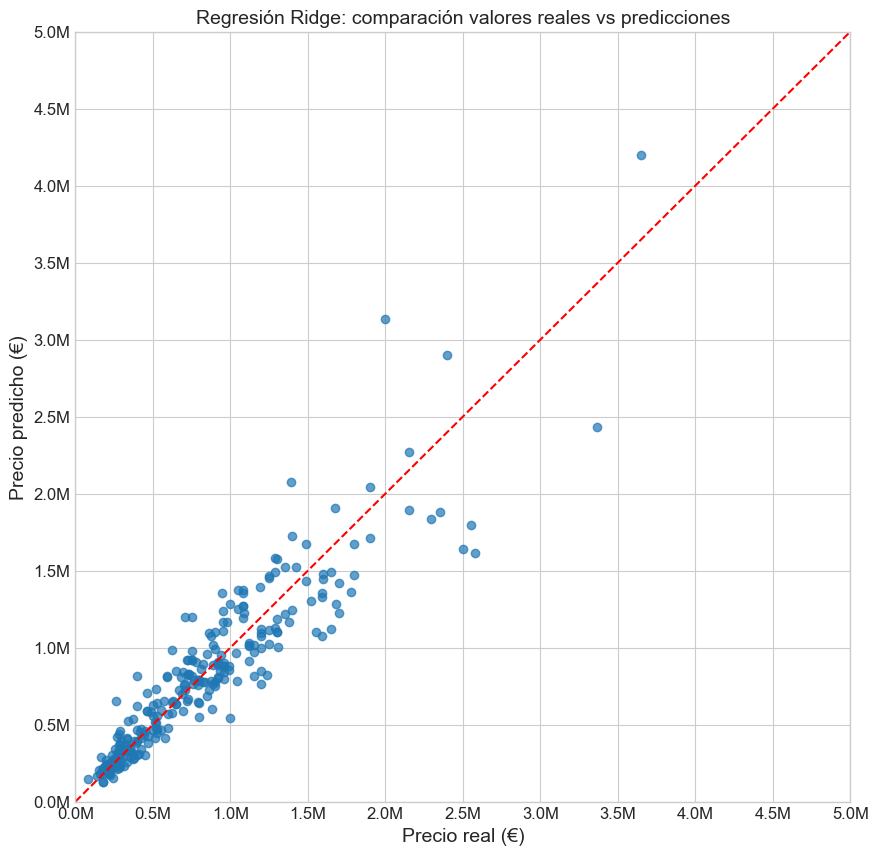


Resultados guardados:
{'RMSE val (original)': np.float64(222212.53006589142), 'MAPE val (original)': 18.70029159745696}


In [43]:
# para modelo Ridge, hiperparámetros mejores ()'alpha': 0.01, 'fit_intercept': True, 'max_iter': 1000, 'solver': 'lsqr'):
# Definir el mejor modelo (Ridge optimizado)
mejor_modelo = Ridge(alpha=0.01, fit_intercept=True, max_iter=1000, solver='lsqr')

# Entrenar el modelo con los datos de entrenamiento (suponiendo que ya tienes X_train y y_train)
mejor_modelo.fit(X_train, y_train)

# Realizar predicciones en la escala logarítmica
y_pred_log = mejor_modelo.predict(X_val)

# Transformar las predicciones y los valores reales de vuelta a la escala original
y_val_original = np.exp(y_val)  # Transformar los valores reales
y_pred_original = np.exp(y_pred_log)  # Transformar las predicciones

# Evaluar el rendimiento del modelo en la escala original
rmse_final = np.sqrt(mean_squared_error(y_val_original, y_pred_original))
mape_final = mean_absolute_percentage_error(y_val_original, y_pred_original) * 100

# Imprimir las métricas finales
print("Métricas finales del mejor modelo (Regresión Ridge):")
print(f"RMSE: {rmse_final:.4f} €")
print(f"MAPE: {mape_final:.4f} %")

# Visualizar las predicciones vs los valores reales
plt.figure(figsize=(10, 10))  # Hacer el gráfico cuadrado

# Ajustar los límites de los ejes para que lleguen hasta 10M
plt.xlim(0, 5e6)
plt.ylim(0, 5e6)

# Visualizar
plt.scatter(y_val_original, y_pred_original, alpha=0.7)
plt.plot([0, 5e6], [0, 5e6], 'r--')  # Línea de referencia 45º

# Etiquetas
plt.xlabel('Precio real (€)', fontsize=14)
plt.ylabel('Precio predicho (€)', fontsize=14)
plt.title('Regresión Ridge: comparación valores reales vs predicciones', fontsize=14)

# Ajustar los ejes para que utilicen 0.5M, 1M, 1.5M, etc., hasta 10M
plt.xticks(np.arange(0, 5.5e6, step=0.5e6), 
           labels=[f'{x/1e6}M' for x in np.arange(0, 5.5e6, step=0.5e6)])

plt.yticks(np.arange(0, 5.5e6, step=0.5e6), 
           labels=[f'{y/1e6}M' for y in np.arange(0, 5.5e6, step=0.5e6)])
plt.show()

# Guardar resultados para análisis posterior
resultados = {
    'RMSE val (original)': rmse_final,
    'MAPE val (original)': mape_final
}

# Imprimir resultados
print("\nResultados guardados:")
print(resultados)


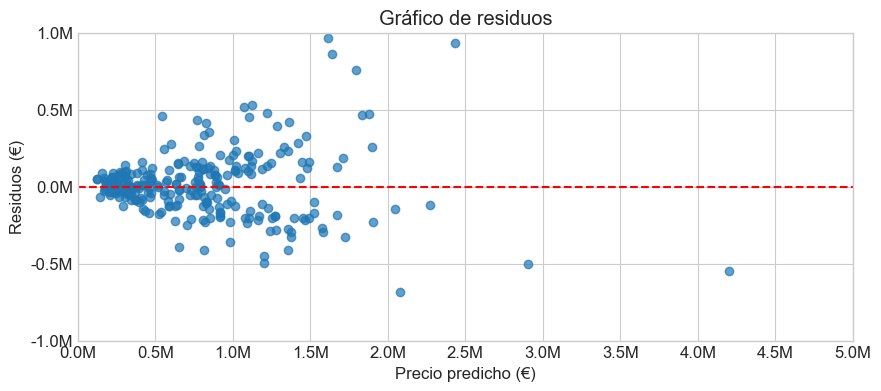

In [44]:
# Gráfico de los residuos de mi modelo.
# Realizamos las predicciones en la escala logarítmica
y_pred_log = mejor_modelo.predict(X_val)

# Transformamos las predicciones a la escala original (elevando a la exponencial)
y_val_original = np.exp(y_val)
y_pred_original = np.exp(y_pred_log)

# Calculamos los residuos
residuos = y_val_original - y_pred_original

# Visualizamos los residuos
plt.figure(figsize=(10, 4))

# Ajustar los límites de los ejes para que lleguen hasta 10M
plt.xlim(0, 5e6)
plt.ylim(-1e6, 1e6)

plt.scatter(y_pred_original, residuos, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')  # Línea horizontal en 0


plt.xlabel('Precio predicho (€)')
plt.ylabel('Residuos (€)')
plt.title('Gráfico de residuos')

# Ajustar los ejes para que utilicen 0.5M, 1M, 1.5M, etc., hasta 10M
plt.xticks(np.arange(0, 5.5e6, step=0.5e6), 
           labels=[f'{x/1e6}M' for x in np.arange(0, 5.5e6, step=0.5e6)])

plt.yticks(np.arange(-1e6, 1.01e6, step=0.5e6), 
           labels=[f'{y/1e6}M' for y in np.arange(-1e6, 1.01e6, step=0.5e6)])

plt.grid(True)
plt.show()


<a id="explicacion"></a>
<a href="#inicio-notebook"><p style="text-align:right;" href="#inicio-notebook">Volver al inicio</p></a> 
## 21. Explicación del modelo Machine Learning: LIME y SHAP